In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

# Check if we are currently inside the 'notebooks' folder
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [3]:
from src.config import SimConfig
from src.utils.data_processing import load_and_cache_entire_fleet
from src.utils.evaluation import VoyageBenchmarker, print_markdown_table
from src.utils.plotting import plot_simulation_dashboard, plot_benchmarker_results, plot_markov_matrix

from src.solvers import AugmentedHybridSDPSolver, AugmentedBaselineSDPSolver

from src.plants import AugmentedHybridPlant, AugmentedFuelCellOnlyPlant

from src.controllers import (
    build_approach,
    AugmentedFCLockedControl,
    AugmentedPolicyControl,
    AugmentedValueControl,
    AugmentedSDPBaselineControl
)

config = SimConfig()
fleet_data = load_and_cache_entire_fleet(config)

# Initialize benchmarker
exclude_days = [] 
benchmarker = VoyageBenchmarker(fleet_data, config, exclude_days)

Beginning memory staging of all 14 fleet files into RAM...
 -> Day 01 successfully cached in RAM.
 -> Day 02 successfully cached in RAM.
 -> Day 03 successfully cached in RAM.
 -> Day 04 successfully cached in RAM.
 -> Day 05 successfully cached in RAM.
 -> Day 06 successfully cached in RAM.
 -> Day 07 successfully cached in RAM.
 -> Day 08 successfully cached in RAM.
 -> Day 09 successfully cached in RAM.
 -> Day 10 successfully cached in RAM.
 -> Day 11 successfully cached in RAM.
 -> Day 12 successfully cached in RAM.
 -> Day 13 successfully cached in RAM.
 -> Day 14 successfully cached in RAM.

All 14 operational days securely held in RAM. Disk I/O locked.


In [4]:
augmented_approaches = {
    "MacroFuelCellOnlyBaseline": build_approach(
        plant_cls=AugmentedFuelCellOnlyPlant,
        controller_cls=AugmentedSDPBaselineControl,
        solver_cls=AugmentedBaselineSDPSolver,
        is_macro=True
    ),
    "FuelCellOnlyBaseline": build_approach(
        plant_cls=AugmentedFuelCellOnlyPlant,
        controller_cls=AugmentedSDPBaselineControl,
        solver_cls=AugmentedBaselineSDPSolver,
        is_macro=False
    ),
    "MacroHybridBaseline": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedSDPBaselineControl,
        solver_cls=AugmentedBaselineSDPSolver,
        is_macro=True
    ),
    "HybridBaseline": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedSDPBaselineControl,
        solver_cls=AugmentedBaselineSDPSolver,
        is_macro=False
    ),
    "MacroFCLocked": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedFCLockedControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=True
    ),
    "FCLocked": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedFCLockedControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=False
    ),
    "MacroPolicy": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedPolicyControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=True
    ),
    "Policy": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedPolicyControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=False
    ),
    "MacroValue": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedValueControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=True
    ),
    "Value": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedValueControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=False
    ),
}

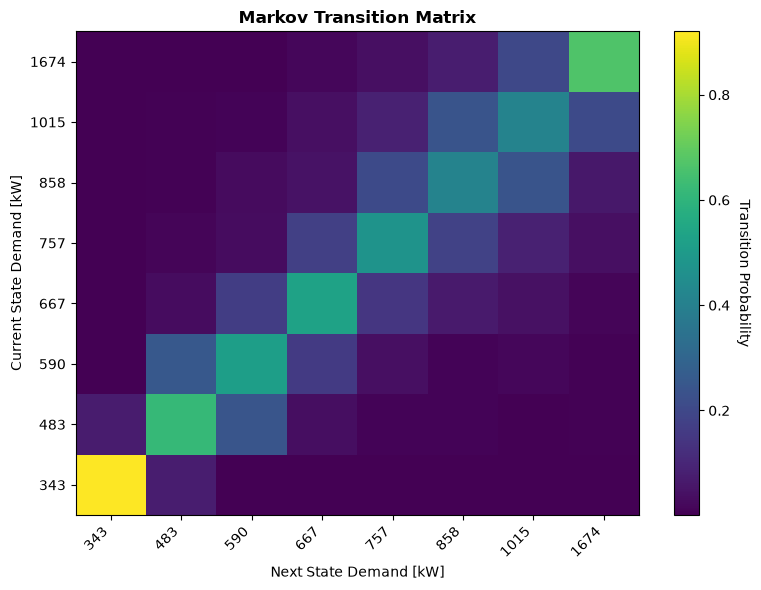

In [5]:
# Manually choose training block and test validation target
train_days = [1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
mc_model, _, _ = benchmarker._get_or_compute_models(train_days, solver_cls=None, horizon_length=1)
plot_markov_matrix(mc_model)
test_day = 4
approaches = augmented_approaches

--- APPROACH A: HAND-PICKED EVALUATION ---
| Strategy                  | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|---------------------------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| MacroFuelCellOnlyBaseline | 7478.47        | 6070.52            | 412.50             | 0.00             | 657.96             | 337.50                | 0.00               | 1.82                     | 0.00                    |
| FuelCellOnlyBaseline      | 37072.12       | 6338.94            | 375.00             | 0.00             | 29983.18           | 375.00                | 0.00               | 1.82                     | 0.21                    |
| MacroHybridBaseline       | 7478.47        | 60

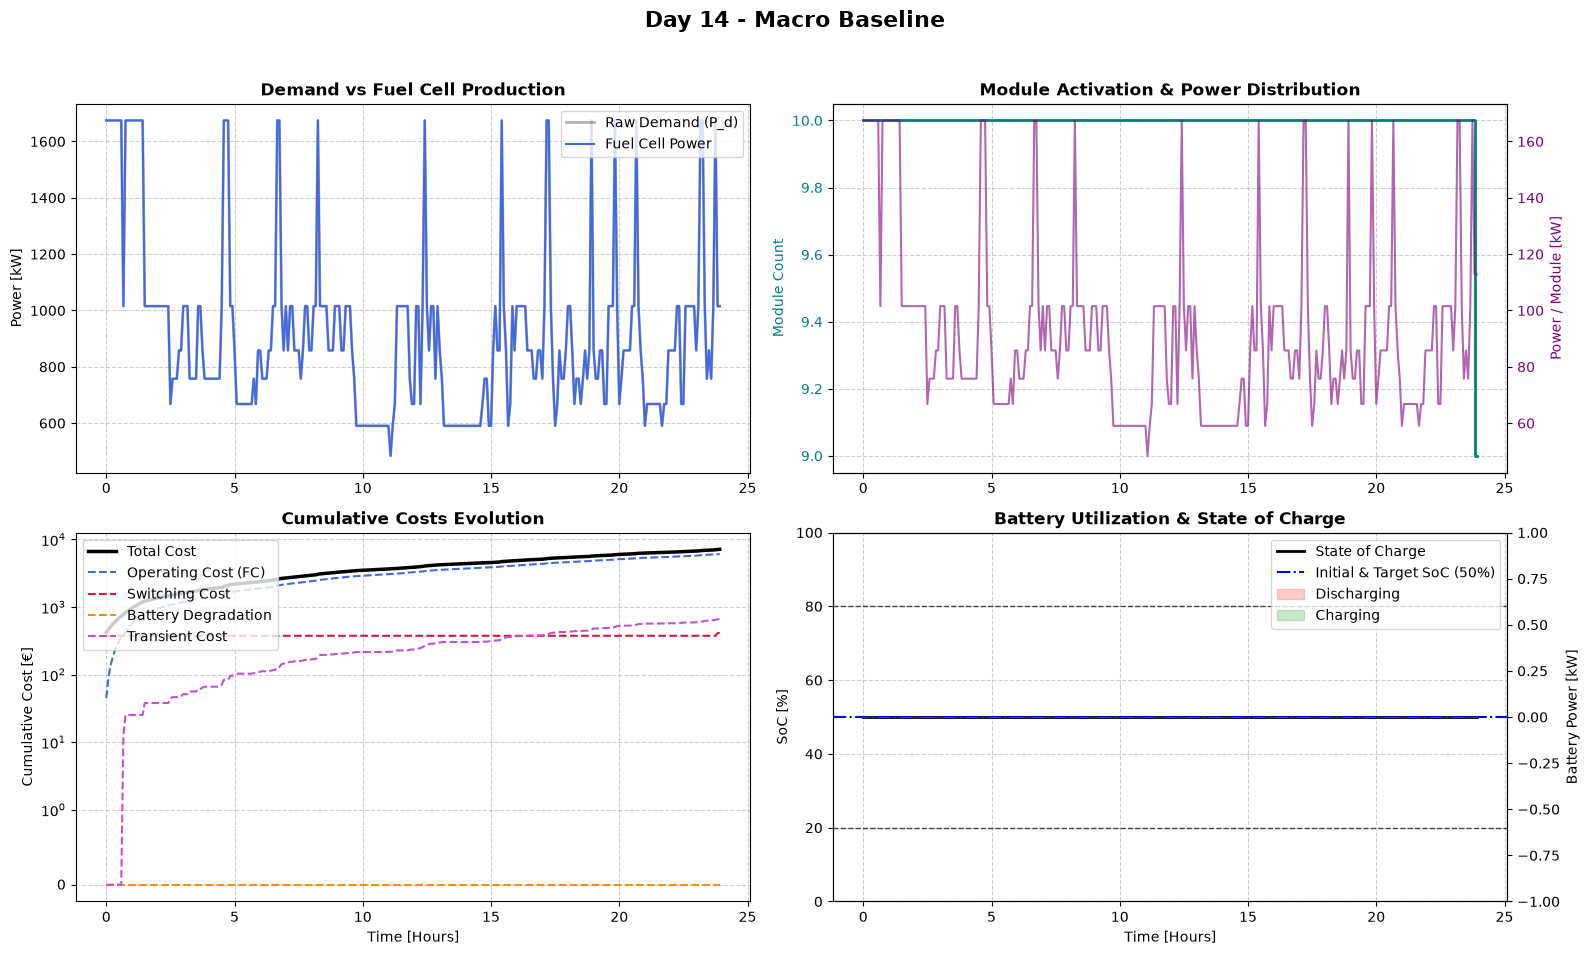

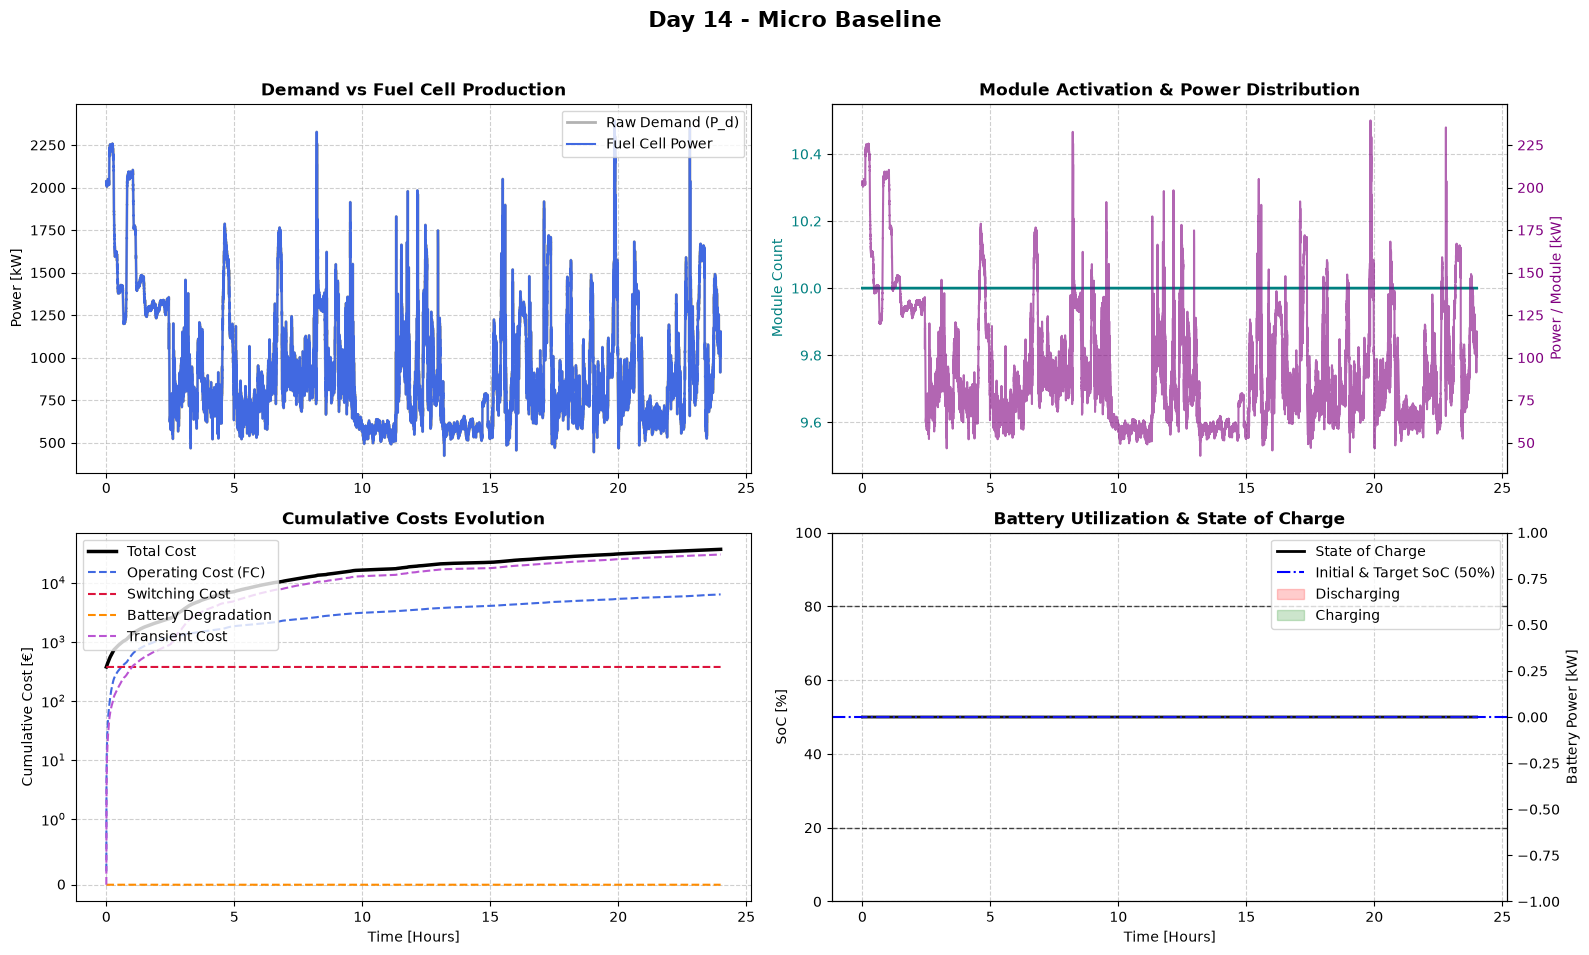

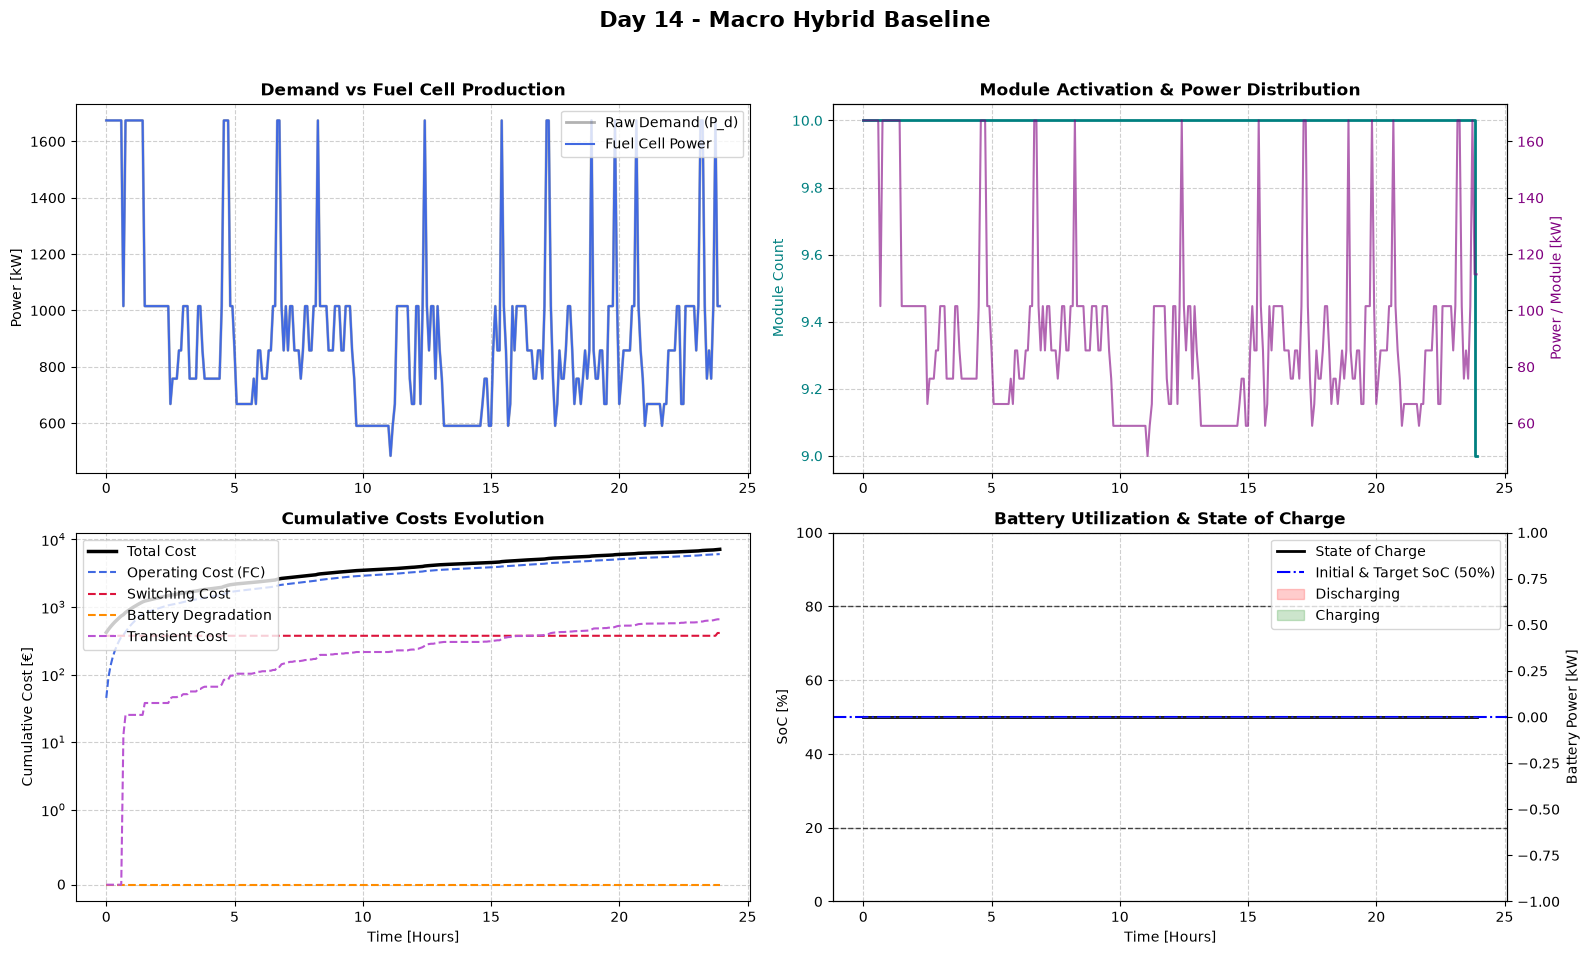

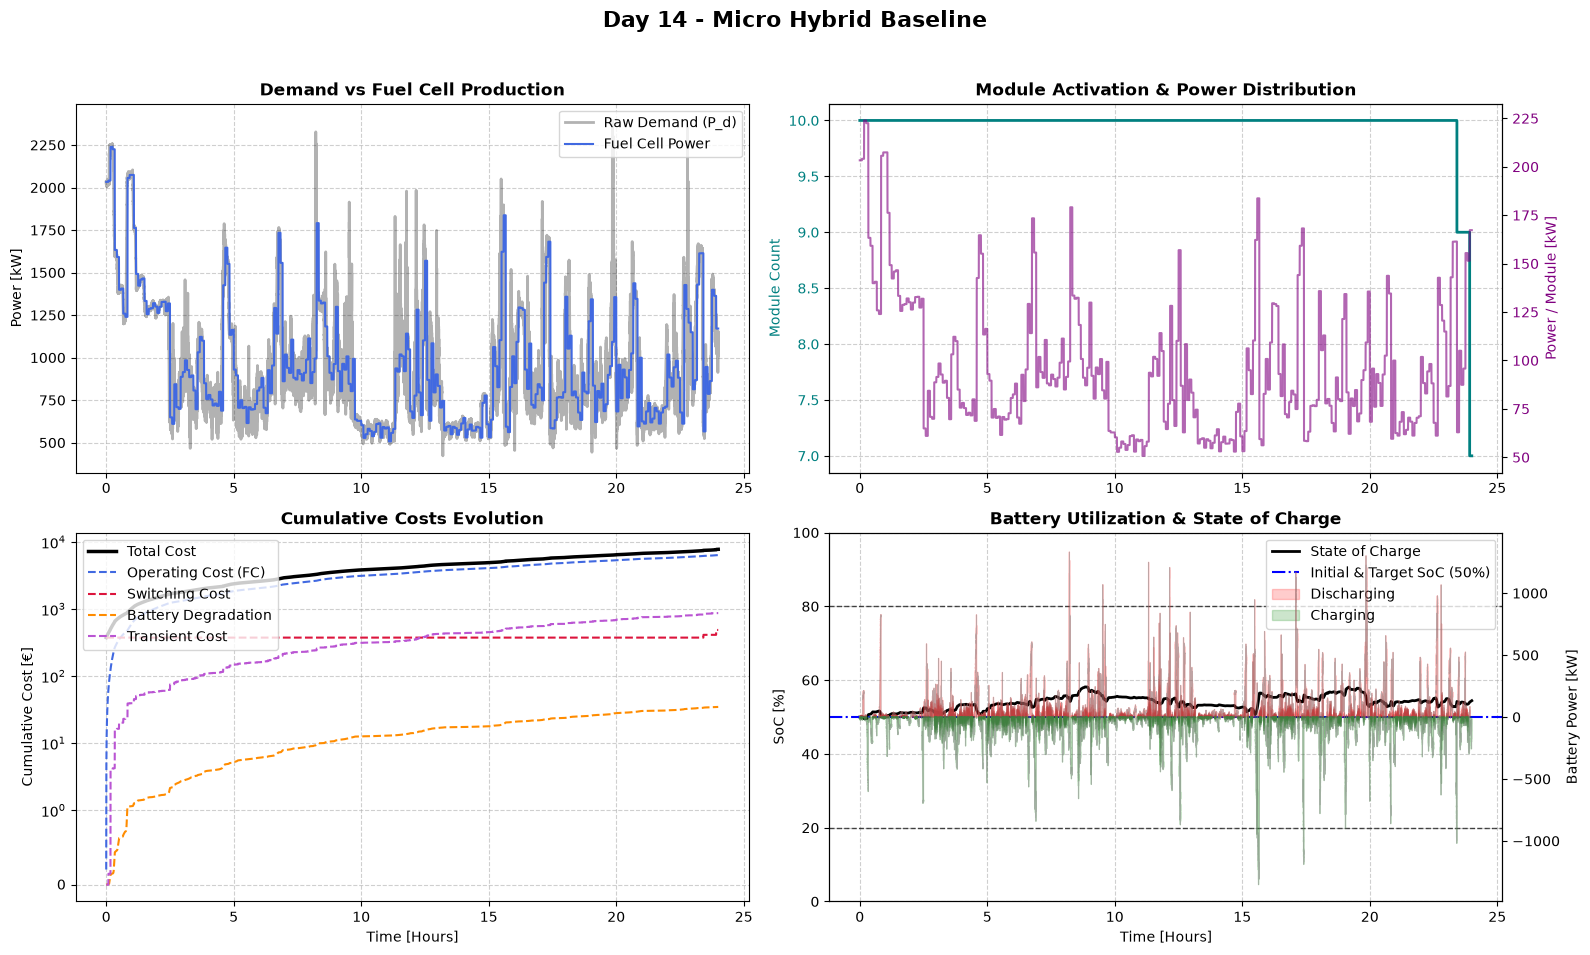

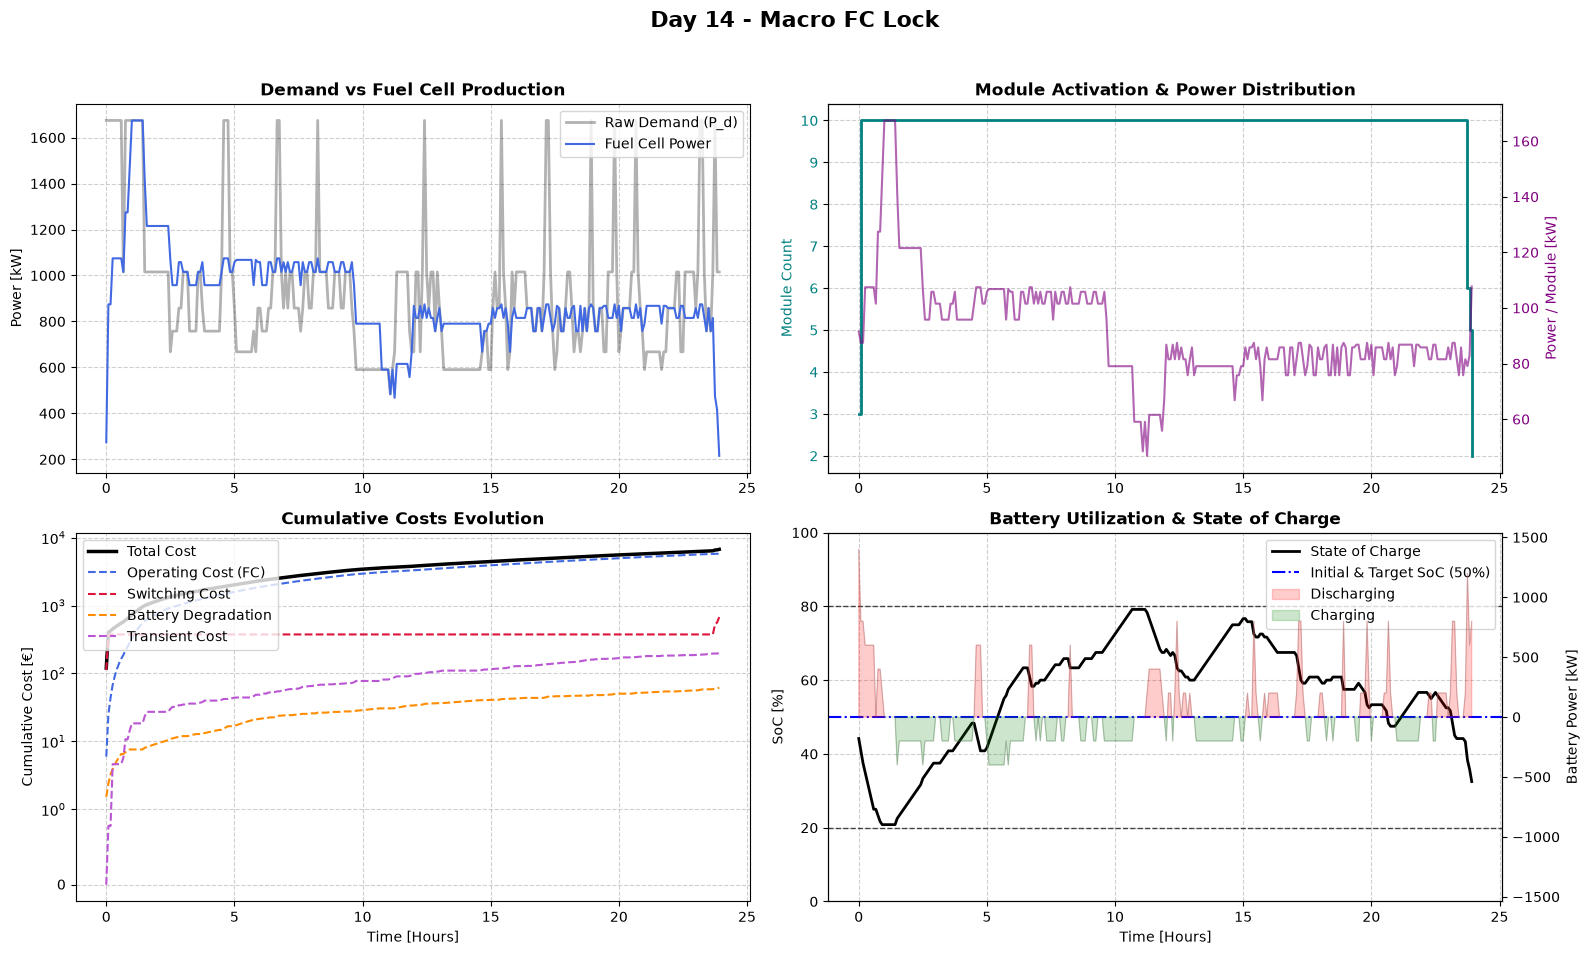

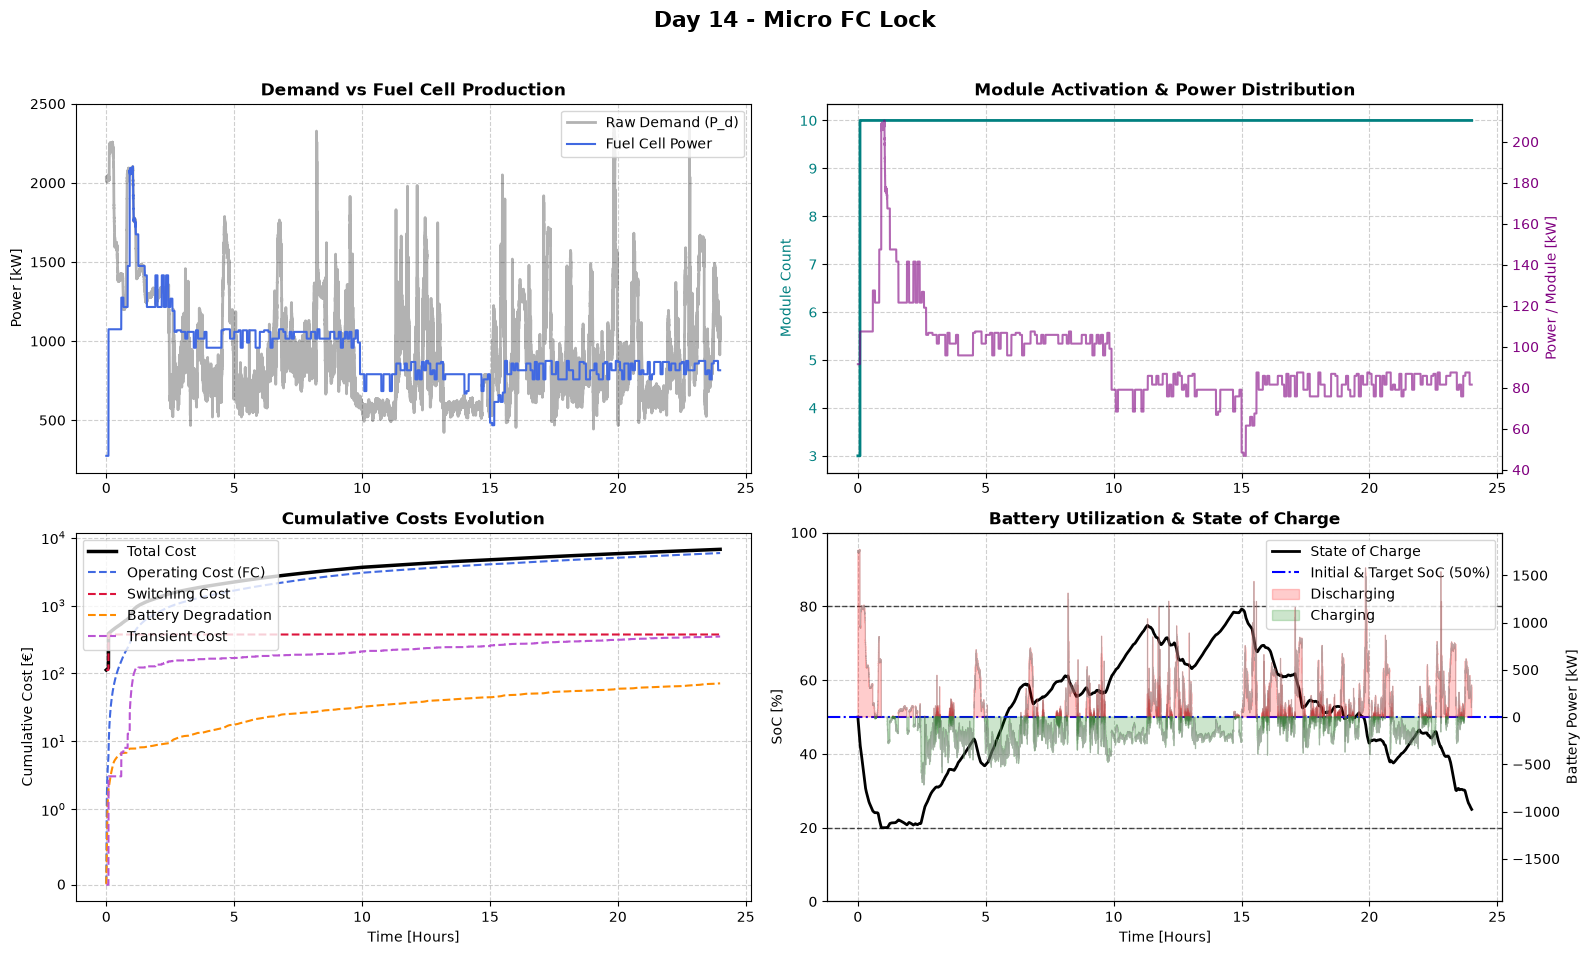

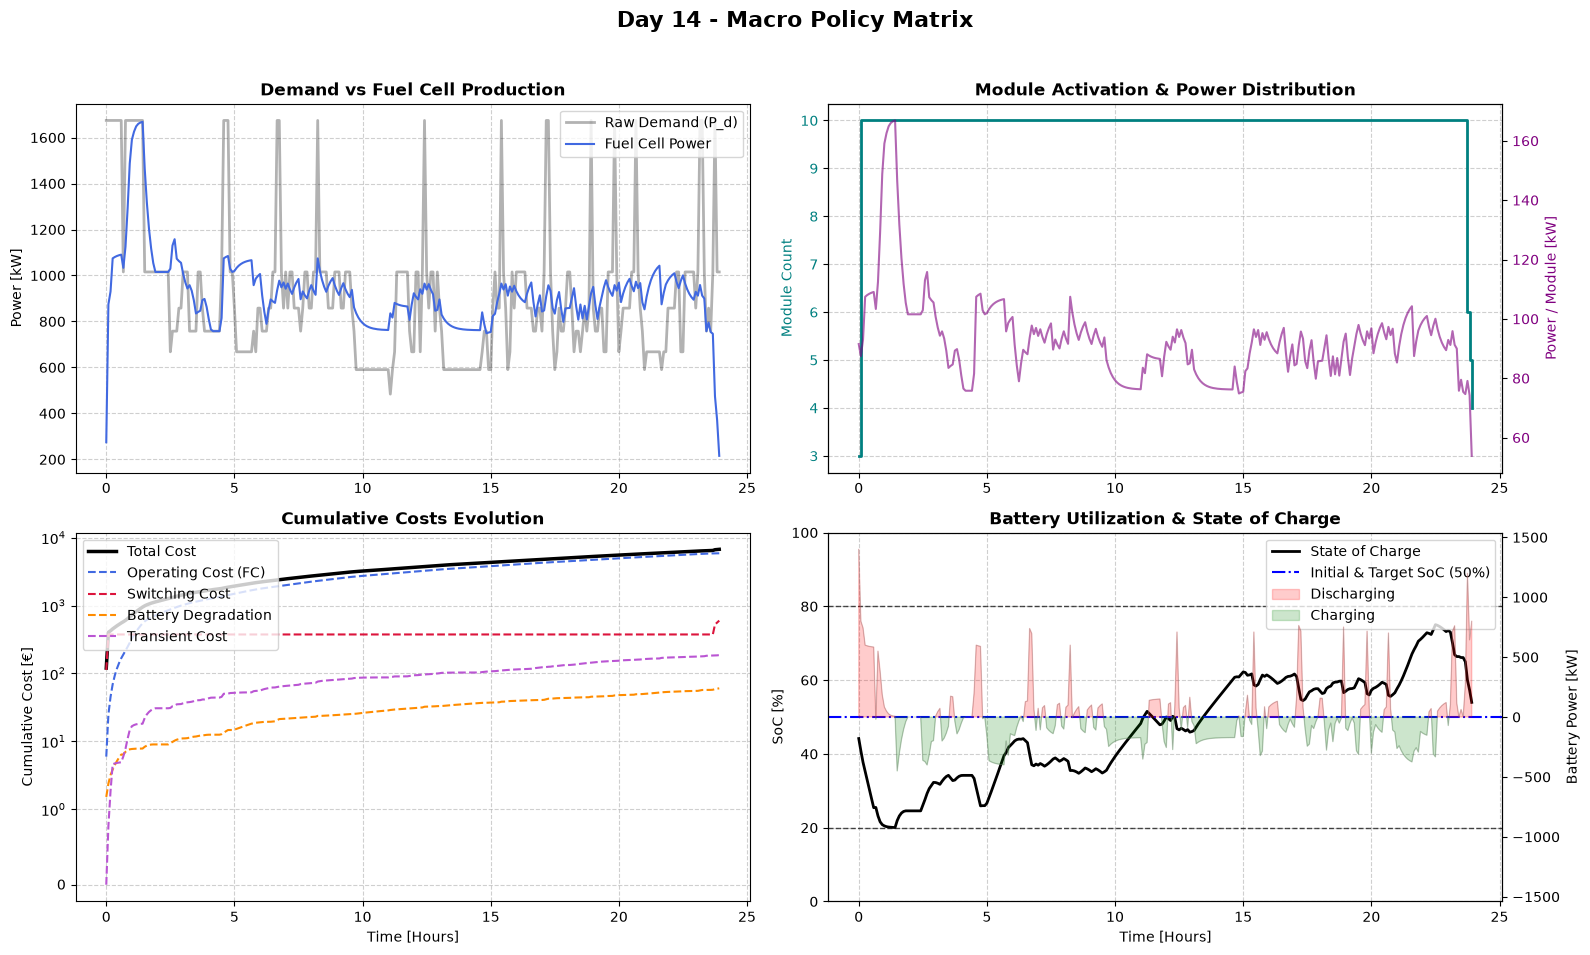

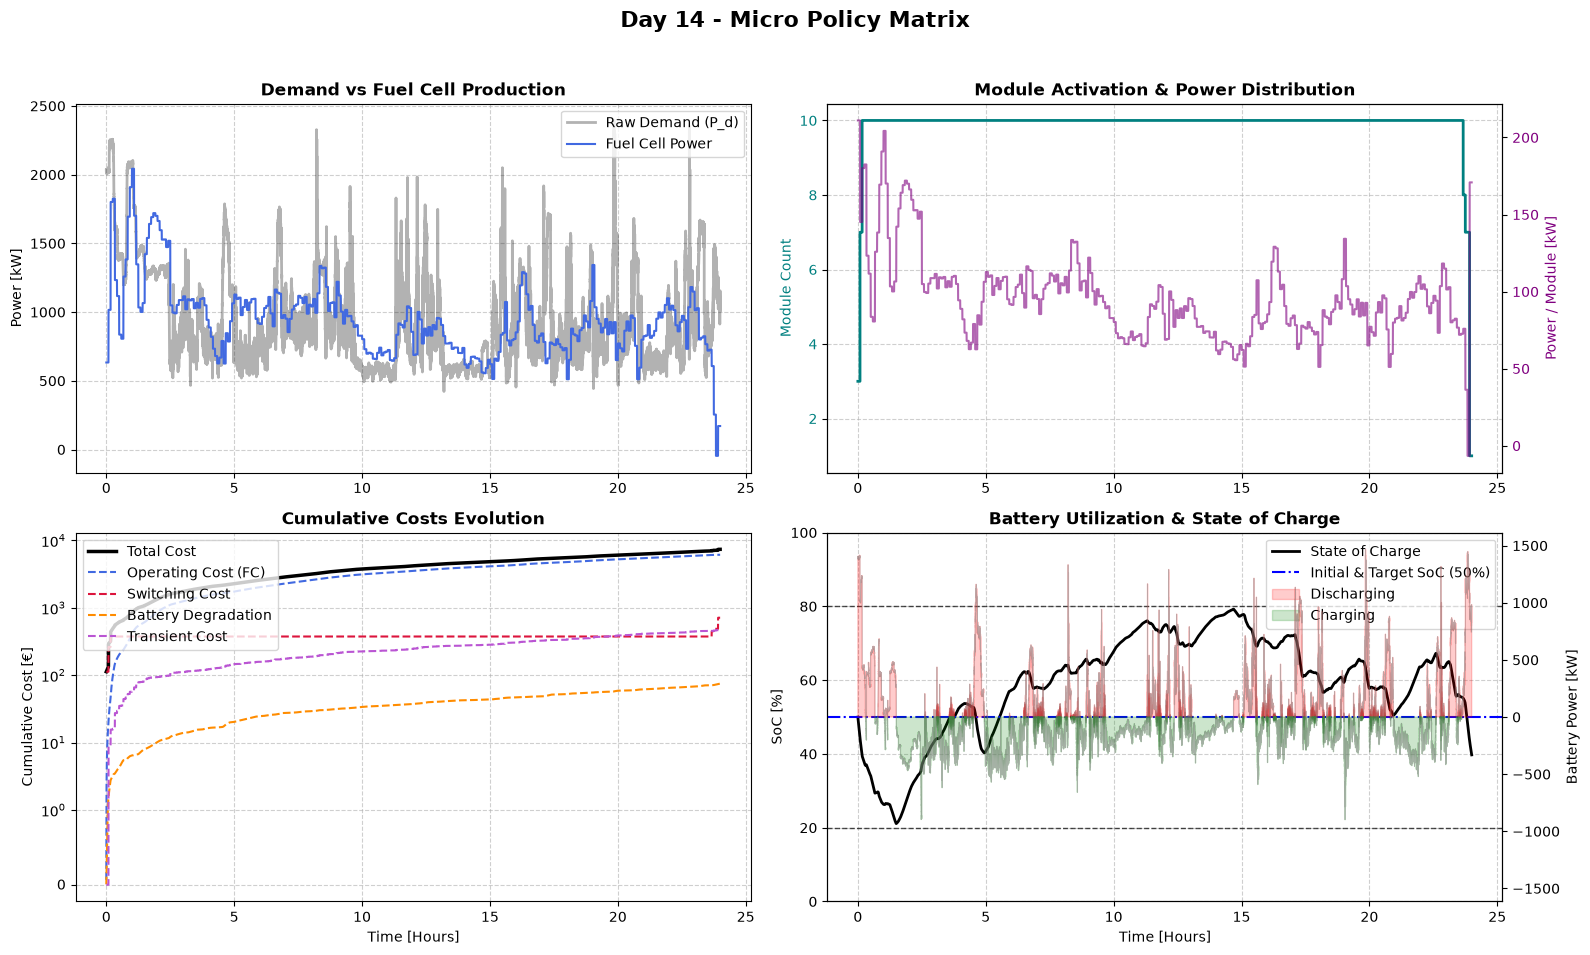

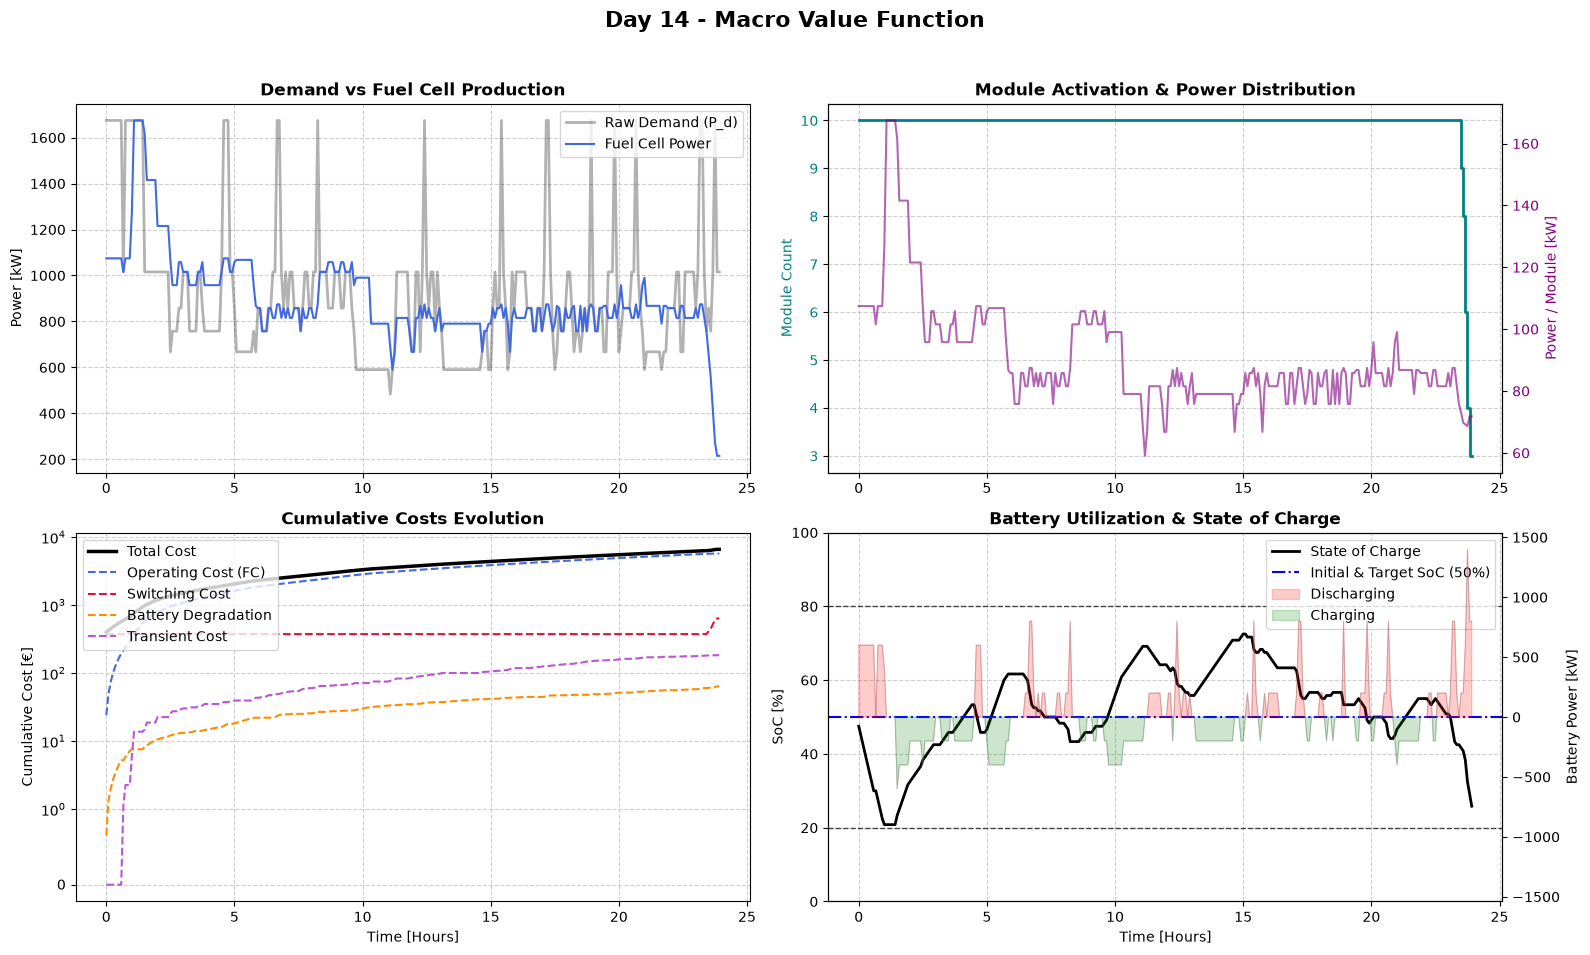

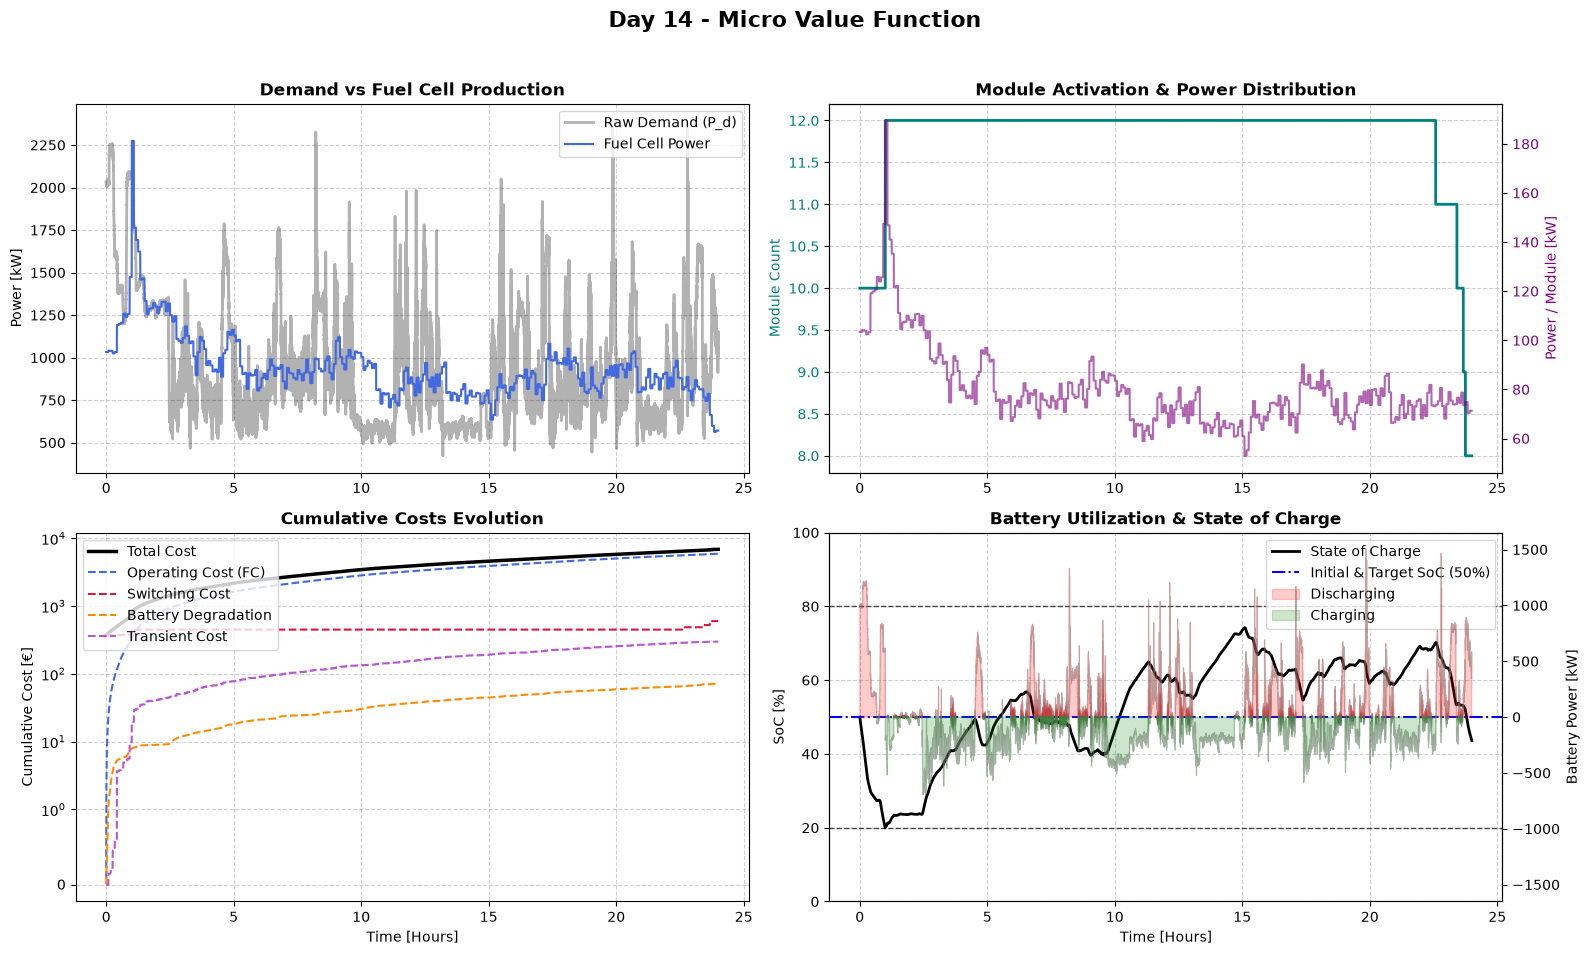

In [9]:
print("--- APPROACH A: HAND-PICKED EVALUATION ---")

report = benchmarker.compare_approaches(approaches, train_days, test_day)
print_markdown_table(report.summary)


plot_simulation_dashboard(report.get_telemetry("MacroFuelCellOnlyBaseline"), benchmarker.config, title="Day 14 - Macro Baseline", indiv=False)
plot_simulation_dashboard(report.get_telemetry("FuelCellOnlyBaseline"), benchmarker.config, title="Day 14 - Micro Baseline", indiv=False)
plot_simulation_dashboard(report.get_telemetry("MacroHybridBaseline"), benchmarker.config, title="Day 14 - Macro Hybrid Baseline", indiv=False)
plot_simulation_dashboard(report.get_telemetry("HybridBaseline"), benchmarker.config, title="Day 14 - Micro Hybrid Baseline", indiv=False)
plot_simulation_dashboard(report.get_telemetry("MacroFCLocked"), benchmarker.config, title="Day 14 - Macro FC Lock", indiv=False)
plot_simulation_dashboard(report.get_telemetry("FCLocked"), benchmarker.config, title="Day 14 - Micro FC Lock", indiv=False)
plot_simulation_dashboard(report.get_telemetry("MacroPolicy"), benchmarker.config, title="Day 14 - Macro Policy Matrix", indiv=False)
plot_simulation_dashboard(report.get_telemetry("Policy"), benchmarker.config, title="Day 14 - Micro Policy Matrix", indiv=False)
plot_simulation_dashboard(report.get_telemetry("MacroValue"), benchmarker.config, title="Day 14 - Macro Value Function", indiv=False)
plot_simulation_dashboard(report.get_telemetry("Value"), benchmarker.config, title="Day 14 - Micro Value Function", indiv=False)




--- APPROACH B: LEAVE-ONE-OUT (Discrete Tracking vs Baseline) ---
 [Vault] Cache MISS: Training Markov Chain for days [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Mar

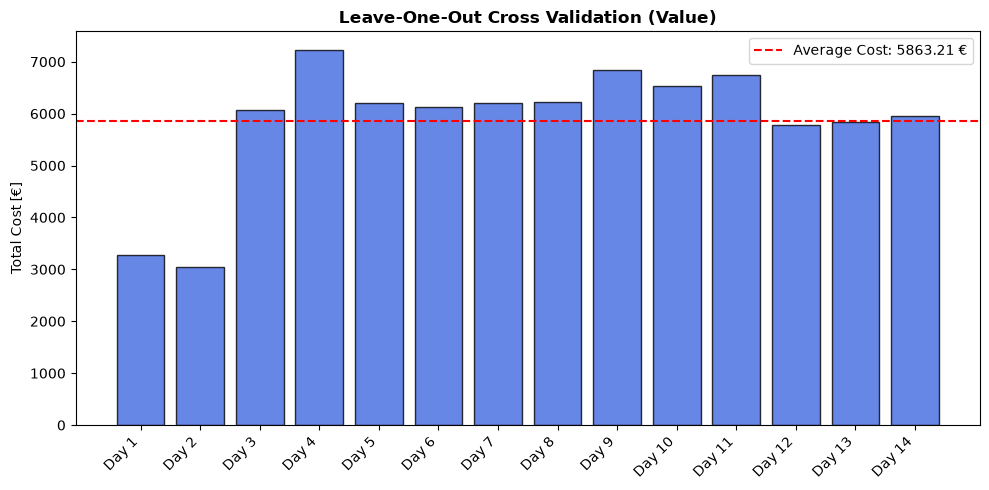

| Strategy | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 3268.18        | 2602.03            | 525.00             | 17.91            | 181.32             | 75.00                 | -133.09            | 47.88                    | 0.48                    |
| Day 2    | 3052.99        | 2498.17            | 337.50             | 14.67            | 164.06             | 187.50                | -148.91            | 47.14                    | 0.30                    |
| Day 3    | 6063.01        | 4820.66            | 450.00             | 27.73            | 163.59             | 450.00                | 151.02             | 60.

In [7]:
print("\n--- APPROACH B: LEAVE-ONE-OUT (Discrete Tracking vs Baseline) ---")

# Note: Running LOO on all 5 approaches might take a couple of minutes due to 4D solves.
# Let's compare the main engineering deployable hybrid against the legacy baseline.

# for app in approaches:
for app in ["Value"]:
    report = benchmarker.run_leave_one_out(approaches[app])
    plot_benchmarker_results(report.summary, title=f"Leave-One-Out Cross Validation ({app})", plot_type='bar')
    print_markdown_table(report.summary)




--- APPROACH C: FORWARD CHAINING (Learning Curve) ---
 [Vault] Cache MISS: Training Markov Chain for days [1]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3, 4]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3, 4, 5]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3, 4, 5, 6]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3, 4, 5

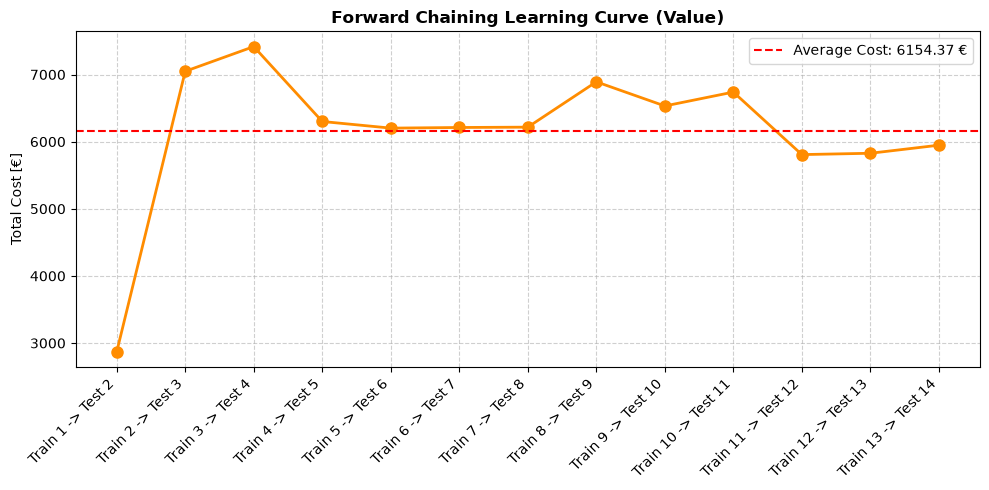

| Strategy            | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|---------------------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Train 1 -> Test 2   | 2869.47        | 2201.17            | 187.50             | 11.70            | 161.69             | 187.50                | 119.91             | 48.75                    | 0.29                    |
| Train 2 -> Test 3   | 7048.23        | 4896.41            | 1200.00            | 15.44            | 408.15             | 375.00                | 153.24             | 51.84                    | 0.41                    |
| Train 3 -> Test 4   | 7416.06        | 5898.92            | 712.50             | 65.21            | 476.20        

In [8]:
print("\n--- APPROACH C: FORWARD CHAINING (Learning Curve) ---")
# Evaluate how the policy improves as the agent gathers chronological data
# Using the Lookahead Optimum to see the absolute theoretical ceiling of the ship's capabilities

# for app in approaches:
for app in ["Value"]:
    report = benchmarker.run_forward_chaining(approaches[app])
    plot_benchmarker_results(report.summary, title=f"Forward Chaining Learning Curve ({app})", plot_type='line')
    print_markdown_table(report.summary)